# Project: Teaching an LLM to Reason

Completed code-only version of the final project notebook.
Run this in the cloud environment with the Python (venv2) Jupyter kernel.


In [3]:
# Load ipython-autotime to see how long each cell takes to run.
# Pin Triton before importing unsloth/vLLM. The cloud venv can be read-only,
# so install compatible packages into a writable target directory and put it
# first on sys.path before any torch/unsloth/vLLM imports.
import os
import shutil
import subprocess
import sys

PATCHED_PACKAGE_DIR = "/tmp/gen_ai_project_python_packages"
os.makedirs(PATCHED_PACKAGE_DIR, exist_ok=True)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--target",
    PATCHED_PACKAGE_DIR,
    "--upgrade",
    "--no-deps",
    "triton==3.2.0",
    "ipython-autotime",
])

if PATCHED_PACKAGE_DIR not in sys.path:
    sys.path.insert(0, PATCHED_PACKAGE_DIR)

shutil.rmtree(os.path.expanduser("~/.triton/cache"), ignore_errors=True)

%load_ext autotime


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 12.8 s (started: 2026-07-12 04:08:42 +00:00)


In [4]:
# Verify we have enough GPU memory to run this project.
!nvidia-smi


Sun Jul 12 04:08:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# Load Qwen2.5-3B-Instruct and configure LoRA.
# Rank 64 balances adapter capacity with T4 memory use.
# All attention and MLP projection modules are targeted so the adapter can
# learn both procedural reasoning and the required output format.

import unsloth

from unsloth import FastLanguageModel
import torch

max_seq_length = 384
lora_rank = 64

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-3B-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,
    fast_inference=True,
    max_lora_rank=lora_rank,
    gpu_memory_utilization=0.5,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=lora_rank,
    use_gradient_checkpointing="unsloth",
)


/voc/data/venv2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 07-12 04:09:50 [__init__.py:241] Automatically detected platform cuda.
ERROR 07-12 04:09:54 [fa_utils.py:57] Cannot use FA version 2 is not supported due to FA2 is only supported on devices with compute capability >= 8
🦥 Unsloth Zoo will now patch everything to make training faster!
INFO 07-12 04:10:18 [vllm_utils.py:688] Unsloth: Patching vLLM v1 graph capture
INFO 07-12 04:10:18 [vllm_utils.py:716] Unsloth: Patching vLLM v0 graph capture
==((====))==  Unsloth 2025.9.7: Fast Qwen2 patching. Transformers: 4.55.4. vLLM: 0.10.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.2.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.31. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM 

2026-07-12 04:10:52,076	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 07-12 04:10:52 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=2048.
Unsloth: vLLM Bitsandbytes config using kwargs = {'load_in_8bit': False, 'load_in_4bit': True, 'bnb_4bit_compute_dtype': 'float16', 'bnb_4bit_quant_storage': 'uint8', 'bnb_4bit_quant_type': 'nf4', 'bnb_4bit_use_double_quant': True, 'llm_int8_enable_fp32_cpu_offload': False, 'llm_int8_has_fp16_weight': False, 'llm_int8_skip_modules': ['lm_head', 'multi_modal_projector', 'merger', 'modality_projection', 'model.layers.2.mlp', 'model.layers.3.mlp', 'model.layers.30.mlp'], 'llm_int8_threshold': 6.0}
INFO 07-12 04:10:52 [llm_engine.py:222] Initializing a V0 LLM engine (v0.10.1) with config: model='unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit', speculative_config=None, tokenizer='unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_le

[W712 04:10:57.164782616 socket.cpp:200] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W712 04:10:57.165388354 socket.cpp:200] [c10d] The hostname of the client socket cannot be retrieved. err=-3


...

Capturing CUDA graph shapes: 100%|██████████| 27/27 [00:25<00:00,  1.05it/s]

INFO 07-12 04:12:16 [model_runner.py:1535] Graph capturing finished in 26 secs, took 0.56 GiB
INFO 07-12 04:12:16 [vllm_utils.py:728] Unsloth: Patched vLLM v0 graph capture finished in 26 secs.


INFO 07-12 04:12:17 [llm_engine.py:417] init engine (profile, create kv cache, warmup model) took 37.12 seconds
INFO 07-12 04:12:17 [llm.py:298] Supported_tasks: ['generate']
Unsloth: Just some info: will skip parsing ['layer_norm2', 'layer_norm1', 'q_norm', 'post_feedforward_layernorm', 'post_layernorm', 'pre_feedforward_layernorm', 'input_layernorm', 'norm2', 'post_attention_layernorm', 'k_norm', 'norm1']
Unsloth: Just some info: will skip parsing ['layer_norm2', 'layer_norm1', 'q_norm', 'post_feedforward_layernorm', 'post_layernorm', 'pre_feedforward_layernorm', 'input_layernorm', 'norm2', 'cross_attn_post_attention_layernorm', 'post_attention_layernorm', 'cross_attn_input_layernorm', 'k_norm', 'norm1']


Unsloth 2025.9.7 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


time: 3min 33s (started: 2026-07-12 04:08:55 +00:00)


In [6]:
# Blank-system-prompt baseline.

SYSTEM_PROMPT = """"""
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": USER_PROMPT},
    ],
    tokenize=False,
    add_generation_prompt=True,
)

from vllm import SamplingParams

sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=2048,
)

output = (
    model.fast_generate(
        [text_for_completion],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)


Processed prompts: 100%|██████████| 1/1 [00:05<00:00,  5.67s/it, est. speed input: 5.12 toks/s, output: 2.65 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
In the word "engage", there is only one letter "g".
time: 5.68 s (started: 2026-07-12 04:12:29 +00:00)


In [7]:
# One-shot Chain-of-Thought prompt baseline.

SYSTEM_PROMPT = """
You are an exact letter-counting assistant.

For every question:
1. Read the target letter and word carefully.
2. Spell the word one letter at a time.
3. Number the positions starting at 1.
4. After each letter, state the running count of the target letter.
5. Return the final count as digits only inside <answer> tags.

Use exactly this structure:
<reasoning>
Counting the number of [target letter]'s in the word [word]
1. [letter] - [running count] so far
2. [letter] - [running count] so far
...
</reasoning>
<answer>
[final numeric count]
</answer>

Example:
User: How many of the letter "o" are there in the word "room"?

Assistant:
<reasoning>
Counting the number of o's in the word room
1. r - 0 so far
2. o - 1 so far
3. o - 2 so far
4. m - 2 so far
</reasoning>
<answer>
2
</answer>
"""

USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": USER_PROMPT},
    ],
    tokenize=False,
    add_generation_prompt=True,
)

sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=2048,
)

output = (
    model.fast_generate(
        [text_for_completion],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)


Processed prompts: 100%|██████████| 1/1 [00:07<00:00,  7.04s/it, est. speed input: 36.38 toks/s, output: 13.07 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system

You are an exact letter-counting assistant.

For every question:
1. Read the target letter and word carefully.
2. Spell the word one letter at a time.
3. Number the positions starting at 1.
4. After each letter, state the running count of the target letter.
5. Return the final count as digits only inside <answer> tags.

Use exactly this structure:
<reasoning>
Counting the number of [target letter]'s in the word [word]
1. [letter] - [running count] so far
2. [letter] - [running count] so far
...
</reasoning>
<answer>
[final numeric count]
</answer>

Example:
User: How many of the letter "o" are there in the word "room"?

Assistant:
<reasoning>
Counting the number of o's in the word room
1. r - 0 so far
2. o - 1 so far
3. o - 2 so far
4. m - 2 so far
</reasoning>
<answer>
2
</answer>
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
<reasoning>
Cou

In [8]:
# Create a list of words of different lengths.

ALL_WORDS = [
    "idea",
    "glow",
    "rust",
    "maze",
    "echo",
    "wisp",
    "veto",
    "lush",
    "gaze",
    "knit",
    "fume",
    "plow",
    "void",
    "oath",
    "grim",
    "crisp",
    "lunar",
    "fable",
    "quest",
    "verge",
    "brawn",
    "elude",
    "aisle",
    "ember",
    "crave",
    "ivory",
    "mirth",
    "knack",
    "wryly",
    "onset",
    "mosaic",
    "velvet",
    "sphinx",
    "radius",
    "summit",
    "banner",
    "cipher",
    "glisten",
    "mantle",
    "scarab",
    "expose",
    "fathom",
    "tavern",
    "fusion",
    "relish",
    "lantern",
    "enchant",
    "torrent",
    "capture",
    "orchard",
    "eclipse",
    "frescos",
    "triumph",
    "absolve",
    "gossipy",
    "prelude",
    "whistle",
    "resolve",
    "zealous",
    "mirage",
    "aperture",
    "sapphire",
]

print(len(ALL_WORDS))
ALL_WORDS[:10]


62


['idea',
 'glow',
 'rust',
 'maze',
 'echo',
 'wisp',
 'veto',
 'lush',
 'gaze',
 'knit']

time: 5.2 ms (started: 2026-07-12 04:12:41 +00:00)


In [9]:
# Create the dataset as a Hugging Face Dataset.

from datasets import Dataset
import random


def generate_records():
    for word in ALL_WORDS:
        for letter in sorted(set(word)):
            yield {"words": word, "letters": letter, "counts": word.count(letter)}

        num_letters_not_in_word_left = int(len(word) // 7 + 1)

        random.seed(hash(word))

        all_letters = list("abcdefghijklmnopqrstuvwxyz")

        random.shuffle(all_letters)
        for letter in all_letters:
            if letter not in word:
                yield {"words": word, "letters": letter, "counts": 0}
                num_letters_not_in_word_left -= 1
            if num_letters_not_in_word_left == 0:
                break


ds = Dataset.from_generator(generate_records)
ds[0]


Generating train split: 401 examples [00:00, 7357.27 examples/s]


{'words': 'idea', 'letters': 'a', 'counts': 1}

time: 446 ms (started: 2026-07-12 04:12:41 +00:00)


In [10]:
# Add the full chat prompt to the dataset.

import re
from datasets import load_dataset, Dataset

SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

ds = ds.map(
    lambda x: {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)

ds[0]


Map: 100%|██████████| 401/401 [00:00<00:00, 5328.45 examples/s]


{'words': 'idea',
 'letters': 'a',
 'counts': 1,
 'prompt': [{'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n",
   'role': 'system'},
  {'content': 'How many of the letter "a" are there in the word "idea"',
   'role': 'user'}]}

time: 89.8 ms (started: 2026-07-12 04:12:42 +00:00)


In [11]:
# Untuned dataset baseline.

text = tokenizer.apply_chat_template(
    ds[0]["prompt"], tokenize=False, add_generation_prompt=True
)

sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=1024,
)

output = (
    model.fast_generate(
        [text],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

print(output)


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.65s/it, est. speed input: 63.81 toks/s, output: 39.50 toks/s]

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>
time: 1.65 s (started: 2026-07-12 04:12:42 +00:00)


In [12]:
# Numbering reward function.


def extract_letter_numbering(response):
    """Extract the numbers at the beginning of numbered letter lines."""
    import re

    pattern = r"\n\s*(\d+)\.\s*[a-z]"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return [int(m) for m in matches]
    return []


assert extract_letter_numbering(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [1, 2, 3, 4, 5]


def numbering_reward_func(completions, words, **kwargs) -> list[float]:
    """Reward sequential line numbering and penalize extra numbered lines."""
    responses = [completion[0]["content"] for completion in completions]

    res = []
    for response, word in zip(responses, words):
        reward = 0.0
        word_len = max(len(word), 1)

        for ix, spell_number in enumerate(extract_letter_numbering(response)):
            line_number = ix + 1

            if spell_number == line_number:
                reward += 0.5
            else:
                reward -= 0.5

            if line_number > len(word):
                reward -= 1.0

        res.append(reward / word_len)
    return res


res = numbering_reward_func(
    completions=[
        [
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
1. l - 2 so far
1. l - 2 so far
</reasoning>
<answer>2</answer>"""
            },
        ],
        [
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
</reasoning>
<answer>2</answer>"""
            },
        ],
    ],
    words=["goal", "goal"],
)
print(res)

assert res[1] > res[0], "The better response should have a higher reward"


[-0.5, 0.25]
time: 2.41 ms (started: 2026-07-12 04:12:43 +00:00)


In [13]:
# Spelling reward function.


def extract_spelling(response):
    """Extract the spelled word from numbered letter lines."""
    import re

    pattern = r"\n\s*\d+\.\s*([a-z])"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return "".join([m for m in matches])
    return ""


assert (
    extract_spelling(
        """Here is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
5. l - 2 so far
"""
    )
    == "goall"
)


def spelling_reward_func(completions, words, **kwargs) -> list[float]:
    """Reward exact spelling and penalize extra, missing, or inserted letters."""
    from collections import Counter

    responses = [completion[0]["content"] for completion in completions]

    res = []

    for word, response in zip(words, responses):
        reward = 0.0

        spelling = extract_spelling(response)
        target_counts = Counter(word.lower())
        response_counts = Counter(spelling.lower())

        if spelling.lower() == word.lower():
            reward += 2.0

        reward -= 0.5 * abs(len(spelling) - len(word))

        extra_letters = response_counts - target_counts
        reward -= 1.0 * sum(extra_letters.values())

        missing_letters = target_counts - response_counts
        reward -= 0.5 * sum(missing_letters.values())

        res.append(reward)
    return res


res = spelling_reward_func(
    completions=[
        [
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
5. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
        [
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
    ],
    words=["goal", "goal"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


[-1.5, 2.0]
time: 58.1 ms (started: 2026-07-12 04:12:43 +00:00)


In [14]:
# Running-count reward function.


def get_resp_letters_and_counts(response):
    """Extract letters and running counts from numbered letter lines."""
    import re

    pattern = r"\n\s*(\d+)\.\s*([a-z])\D*(\d+)"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)

    if not matches:
        return []

    return [
        (matched_letter, matched_count_so_far)
        for _, matched_letter, matched_count_so_far in matches
    ]


assert get_resp_letters_and_counts(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [("g", "1"), ("o", "1"), ("a", "2"), ("a", "2"), ("l", "2")]


def counting_reward_func(completions, letters, **kwargs) -> list[float]:
    """Reward accurate running count of the target letter."""
    responses = [completion[0]["content"] for completion in completions]

    res = []

    for letter, response in zip(letters, responses):
        reward = 0.0
        target_letter = str(letter).lower()

        letters_and_counts = get_resp_letters_and_counts(response)

        if not letters_and_counts:
            res.append(-1.0)
            continue

        actual_count = 0
        for resp_letter, resp_count in letters_and_counts:
            if target_letter == resp_letter.lower():
                actual_count += 1

            if actual_count == int(resp_count):
                reward += 1.0
            else:
                reward -= 1.0

        res.append((reward / len(letters_and_counts)) * 2.0)
    return res


res = counting_reward_func(
    completions=[
        [
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 0 so far
2. o - 0 so far
3. a - 1 so far
4. a - 2 so far
5. l - 0 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
        [
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 1 so far
4. a - 1 so far
5. l - 1 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
    ],
    letters=["g", "g"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


[-1.2, 2.0]
time: 52.6 ms (started: 2026-07-12 04:12:44 +00:00)


In [15]:
# Formatting reward function.


def extract_xml_answer(text: str) -> str:
    """Extract the string between <answer> and </answer> tags."""
    import re

    pattern = r"<answer>(.*?)</answer>"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""


assert (
    extract_xml_answer("""
<reasoning>
This is my reasoning.
</reasoning>
<answer>SUPERCALIFRAGILISTICEXPIALIDOCIOUS</answer>
""")
    == "SUPERCALIFRAGILISTICEXPIALIDOCIOUS"
)


def format_reward_func(completions, **kwargs) -> list[float]:
    """Reward required XML-style format and numeric final answer."""
    pattern = r"\s*<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"

    res = []

    for completion in completions:
        reward = 0.0
        response = completion[0]["content"]

        match = re.match(pattern, response, flags=re.MULTILINE | re.DOTALL)

        if match:
            reward += 0.5

        extracted_answer = extract_xml_answer(response)

        if extracted_answer.isdigit():
            reward += 0.5

        res.append(reward)
    return res


res = format_reward_func(
    completions=[
        [{"content": "This is my answer"}],
        [
            {
                "content": "<reasoning>\nThis is my reasoning.\n</reasoning>\n<answer>\n3\n</answer>"
            }
        ],
    ]
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


[0.0, 1.0]
time: 62.9 ms (started: 2026-07-12 04:12:44 +00:00)


In [16]:
# Correct-final-answer reward function.


def correct_answer_reward_func(prompts, completions, counts, **kwargs) -> list[float]:
    """Reward the final answer if it is correct."""
    responses = [completion[0]["content"] for completion in completions]

    extracted_responses = [extract_xml_answer(r) for r in responses]

    print(f"""
{"-" * 20}
Question: {prompts[0][-1]["content"]}
Answer: {counts[0]}
Response: {responses[0]}
Extracted: {extracted_responses[0]}
Correct: {str(extracted_responses[0]).strip() == str(counts[0]).strip()}!
    """)

    res = [
        2.0 if str(r).strip() == str(a).strip() else -1.0
        for r, a in zip(extracted_responses, counts)
    ]
    return res


res = correct_answer_reward_func(
    prompts=[
        [{"content": """How many..."""}],
        [{"content": """How many..."""}],
    ],
    completions=[
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
    ],
    letters=["g", "g"],
    counts=[0, 3],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"



--------------------
Question: How many...
Answer: 0
Response: <reasoning>.../reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    
[-1.0, 2.0]
time: 54 ms (started: 2026-07-12 04:12:44 +00:00)


In [17]:
# List reward functions.

REWARD_FUNCS = [
    numbering_reward_func,
    spelling_reward_func,
    counting_reward_func,
    format_reward_func,
    correct_answer_reward_func,
]


time: 52.4 ms (started: 2026-07-12 04:12:44 +00:00)


In [18]:
# GRPO training parameters.

COMMON_GRPO_TRAINING_PARAMS = dict(
    learning_rate=1e-5,
    beta=0.0001,
    per_device_train_batch_size=16,
    num_generations=4,
    gradient_accumulation_steps=1,
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    logging_steps=1,
    max_prompt_length=256,
    max_completion_length=200,
    num_train_epochs=1,
    save_steps=250,
    max_grad_norm=0.1,
    report_to="none",
    output_dir="outputs",
    use_vllm=True,
)


time: 51.6 ms (started: 2026-07-12 04:12:44 +00:00)


In [19]:
# Quick 5-step training run.

from trl import GRPOConfig, GRPOTrainer

training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    max_steps=5,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)

trainer_res = trainer.train()


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 119,734,272 of 3,205,672,960 (3.74% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. i - 1 so far
3. n - 1 so far
4. s - 1 so far
5. t - 1 so far
6. e - 1 so far
7. l - 1 so far
8. n - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.000000,2.706820,2.607508,85.875000,39.000000,111.000000,0.000000,85.875000,39.000000,111.000000,0.000000,0.431920,0.111273,0.031250,2.028700,-0.193849,1.323952,1.000000,0.000000,1.437500,1.209339
2,-0.000000,1.482676,1.352649,79.875000,57.000000,112.000000,0.000000,79.875000,57.000000,112.000000,0.000000,0.441406,0.058044,-0.843750,2.256241,0.197520,1.173014,1.000000,0.000000,0.687500,1.537043
3,0.000000,2.696181,1.803979,81.812500,39.000000,110.000000,0.000000,81.812500,39.000000,110.000000,0.000418,0.441220,0.105809,-0.375000,2.341652,0.942460,1.489820,1.000000,0.000000,0.687500,1.537043
4,0.000000,-0.210417,1.821339,81.625000,74.000000,101.000000,0.000000,81.625000,74.000000,101.000000,0.002041,0.458333,0.052705,-0.031250,2.276465,-0.825000,0.909823,1.000000,0.000000,-0.812500,0.750000
5,0.000000,1.963318,1.165197,80.187500,56.000000,109.000000,0.000000,80.187500,56.000000,109.000000,0.002521,0.420759,0.170405,0.343750,1.921100,-0.113690,1.369511,1.000000,0.000000,0.312500,1.537043


Unsloth: Will smartly offload gradients to save VRAM!

--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word "sapphire"
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. r - 2 so far
6. a - 3 so far
7. p - 3 so far
8. h - 3 so far
9. e - 4 so far
</reasoning>
<answer>
4
</answer>
Extracted: 4
Correct: False!
    

--------------------
Question: How many of the letter "u" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of u's in the word absolve
1. a - 0 so far
2. b - 1 so far
3. s - 2 so far
4. o - 3 so far
5. v - 4 so far
6. e - 5 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: False!
    

--------------------
Question: How many of the letter "g" are there in the word "mirage"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word "mirage"
1. m - 0 so far
2. i - 0 so far
3. r - 0 so far
4. a - 0

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


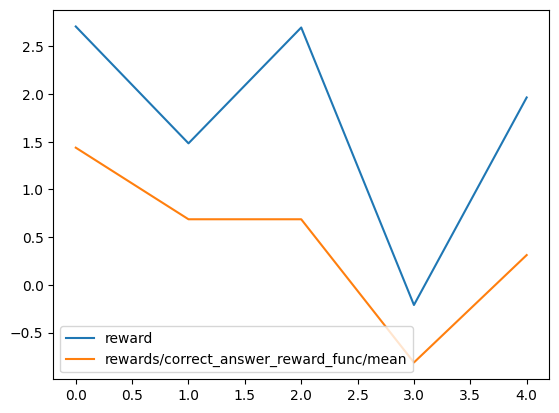

time: 6.28 s (started: 2026-07-12 04:14:22 +00:00)


In [20]:
# Plot quick-run rewards.

import pandas as pd
import matplotlib.pyplot as plt

print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()


In [21]:
# Longer training run.

training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    max_steps=100,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)

trainer_res = trainer.train()


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 119,734,272 of 3,205,672,960 (3.74% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 1 so far
3. i - 1 so far
4. t - 1 so far
5. n - 1 so far
6. s - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.000000,2.649777,2.804607,83.250000,38.000000,156.000000,0.000000,83.250000,38.000000,156.000000,0.011649,0.386384,0.136147,-0.687500,2.072639,0.325893,1.506273,1.000000,0.000000,1.625000,1.024695
2,0.000000,2.283718,0.969531,75.437500,57.000000,111.000000,0.000000,75.437500,57.000000,111.000000,0.002966,0.457031,0.054576,-0.187500,2.250000,-0.048313,1.026020,1.000000,0.000000,1.062500,1.436141
3,0.000000,2.872768,2.659471,83.500000,38.000000,144.000000,0.000000,83.500000,38.000000,144.000000,0.004921,0.435268,0.116559,-0.875000,2.432420,1.437500,0.898175,1.000000,0.000000,0.875000,1.500000
4,0.000000,-0.134077,1.663736,82.187500,74.000000,92.000000,0.000000,82.187500,74.000000,92.000000,0.005154,0.473958,0.039893,-0.031250,2.020468,-0.764286,0.935285,1.000000,0.000000,-0.812500,0.750000
5,0.000000,1.543378,2.346283,79.312500,56.000000,113.000000,0.000000,79.312500,56.000000,113.000000,0.003105,0.432366,0.133856,0.031250,2.036899,-0.232738,1.243932,1.000000,0.000000,0.312500,1.537043
6,0.000000,3.747694,2.030460,78.625000,56.000000,121.000000,0.000000,78.625000,56.000000,121.000000,0.009638,0.433705,0.067120,-0.093750,2.059278,0.970238,1.240247,1.000000,0.000000,1.437500,1.209339
7,0.000000,0.553943,2.273873,76.062500,61.000000,93.000000,0.000000,76.062500,61.000000,93.000000,0.010218,0.387277,0.047344,-1.500000,1.095445,0.354167,1.180262,1.000000,0.000000,0.312500,1.537043
8,0.000000,1.226042,1.500216,88.625000,83.000000,120.000000,0.000000,88.625000,83.000000,120.000000,0.004861,0.434077,0.057062,-1.468750,1.189801,0.385714,1.668851,1.000000,0.000000,0.875000,1.500000
9,0.000000,2.583631,2.986627,89.062500,65.000000,113.000000,0.000000,89.062500,65.000000,113.000000,0.015128,0.433036,0.081658,-1.000000,1.923538,1.088095,0.934483,1.000000,0.000000,1.062500,1.436141
10,0.000000,3.511012,3.387509,76.562500,65.000000,93.000000,0.000000,76.562500,65.000000,93.000000,0.021836,0.453571,0.056695,0.531250,1.726931,0.463690,1.338804,1.000000,0.000000,1.062500,1.436141



--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. a - 3 so far
6. p - 3 so far
7. h - 3 so far
8. e - 4 so far
</reasoning>
<answer>
4
</answer>
Extracted: 4
Correct: False!
    

--------------------
Question: How many of the letter "u" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of u's in the word absolve
1. a - 0 so far
2. b - 0 so far
3. s - 0 so far
4. c - 0 so far
5. o - 0 so far
6. l - 0 so far
7. e - 0 so far
</reasoning>
<answer>
0
</answer>
Extracted: 0
Correct: True!
    

--------------------
Question: How many of the letter "g" are there in the word "mirage"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word mirage
1. m - 0 so far
2. i - 1 so far
3. r - 2 so far
4. a - 3 so far
5. g - 4 so far
6. e - 4 so far
</reasoning>
<answer>
4
</answer>
Extracted: 4
Correct: False!
    

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


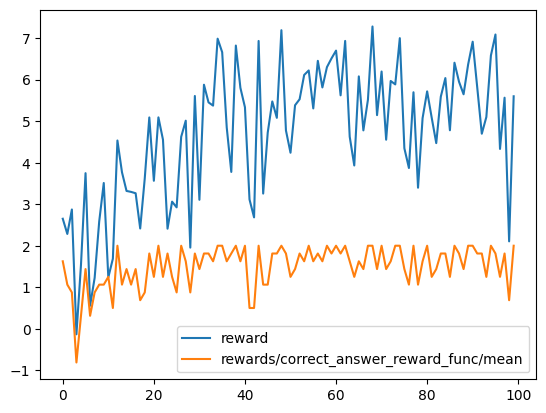

time: 149 ms (started: 2026-07-12 04:37:43 +00:00)


In [22]:
# Plot long-run rewards.

import pandas as pd
import matplotlib.pyplot as plt

print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()


In [23]:
# Save LoRA adapters.

model.save_lora("grpo_saved_lora")


time: 1.27 s (started: 2026-07-12 04:37:43 +00:00)


In [24]:
# Compare original model and saved LoRA adapter.


def compare_old_and_new_model(messages):
    from vllm import SamplingParams

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    sampling_params = SamplingParams(
        temperature=0.8,
        top_p=0.95,
        max_tokens=1024,
    )

    old = (
        model.fast_generate(
            [text],
            sampling_params=sampling_params,
            lora_request=None,
        )[0]
        .outputs[0]
        .text
    )

    new = (
        model.fast_generate(
            [text],
            sampling_params=sampling_params,
            lora_request=model.load_lora("grpo_saved_lora"),
        )[0]
        .outputs[0]
        .text
    )

    print("===OLD===\n")
    print(old)

    print("\n\n===NEW===\n")
    print(new)


time: 1.03 ms (started: 2026-07-12 04:37:44 +00:00)


In [25]:
# Compare old and new models on the first dataset example.

first_example = ds[0]
print(first_example)
compare_old_and_new_model(first_example["prompt"])


{'words': 'idea', 'letters': 'a', 'counts': 1, 'prompt': [{'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n", 'role': 'system'}, {'content': 'How many of the letter "a" are there in the word "idea"', 'role': 'user'}]}


Processed prompts: 100%|██████████| 1/1 [00:05<00:00,  5.53s/it, est. speed input: 19.00 toks/s, output: 11.94 toks/s]

===OLD===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 0 so far
3. e - 0 so far
4. a - 1 so far
</reasoning>
<answer>
1
</answer>


===NEW===

<reasoning>
Counting the number of a's in the word "idea"
1. i - 0 so far
2. d - 0 so far
3. e - 0 so far
4. a - 1 so far
</reasoning>
<answer>
1
</answer>
time: 7.39 s (started: 2026-07-12 04:37:44 +00:00)


In [26]:
# Catastrophic-forgetting check with a general-knowledge question.

general_knowledge_messages = [
    {
        "role": "system",
        "content": "Answer the question clearly and concisely.",
    },
    {
        "role": "user",
        "content": "What is the capital of the Philippines?",
    },
]

compare_old_and_new_model(general_knowledge_messages)


Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s, est. speed input: 37.62 toks/s, output: 11.29 toks/s]

===OLD===

The capital of the Philippines is Manila.


===NEW===

The capital of the Philippines is Manila.
time: 1.15 s (started: 2026-07-12 04:37:52 +00:00)
